# Occlusion Demo

This demo shows the processes for creating facial occlusions to use them in the project as data augmentation. It includes extracting landmarks, generating and applying the occlusion as a mask and opaque glasses adjusted to the landmarks using the utils.apply_occlusion function (in "mask" and "glasses" modes).

In [15]:
import os
import matplotlib.pyplot as plt
import scipy.io as sio
import cv2
import utils
import face_alignment
import torch
import torch._dynamo
torch._dynamo.config.suppress_errors = True
import numpy as np
import shutil

In [12]:
JAW      = slice(0, 17)
EYEBROWS = slice(17, 27)
NOSE     = slice(27, 36)
EYES     = slice(36, 48)
MOUTH    = slice(48, 68)

test_images = [f"./dataset/test/image_{i+1:02d}.png" for i in range(12)]
print(test_images)

['./dataset/test/image_01.png', './dataset/test/image_02.png', './dataset/test/image_03.png', './dataset/test/image_04.png', './dataset/test/image_05.png', './dataset/test/image_06.png', './dataset/test/image_07.png', './dataset/test/image_08.png', './dataset/test/image_09.png', './dataset/test/image_10.png', './dataset/test/image_11.png', './dataset/test/image_12.png']


C:\Users\enric\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\face_alignment\api.py:130: UserWarning: Compiling face alignment model (one-time cost). Subsequent runs will be faster.
  warnings.warn(
W0527 11:55:14.552000 25532 torch\_dynamo\convert_frame.py:1125] WON'T CONVERT forward C:\Users\enric\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\face_alignment\models\fan.py line 133 
W0527 11:55:14.552000 25532 torch\_dynamo\convert_frame.py:1125] due to: 
W0527 11:55:14.552000 25532 torch\_dynamo\convert_frame.py:1125] Traceback (most recent call last):
W0527 11:55:14.552000 25532 torch\_dynamo\convert_frame.py:1125]   File "C:\Users\enric\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\_inductor\cpp_builder.py", line 130, in check_compiler_exist_window

Processing ./dataset/test/image_01.png with shape (720, 1280, 3)
Processing ./dataset/test/image_02.png with shape (720, 1280, 3)
Processing ./dataset/test/image_03.png with shape (720, 1280, 3)
Processing ./dataset/test/image_04.png with shape (720, 1280, 3)
Processing ./dataset/test/image_05.png with shape (720, 1280, 3)
Processing ./dataset/test/image_06.png with shape (720, 1280, 3)
Processing ./dataset/test/image_07.png with shape (720, 1280, 3)
Processing ./dataset/test/image_08.png with shape (720, 1280, 3)
Processing ./dataset/test/image_09.png with shape (720, 1280, 3)
Processing ./dataset/test/image_10.png with shape (720, 1280, 3)
Processing ./dataset/test/image_11.png with shape (720, 1280, 3)
Processing ./dataset/test/image_12.png with shape (720, 1280, 3)


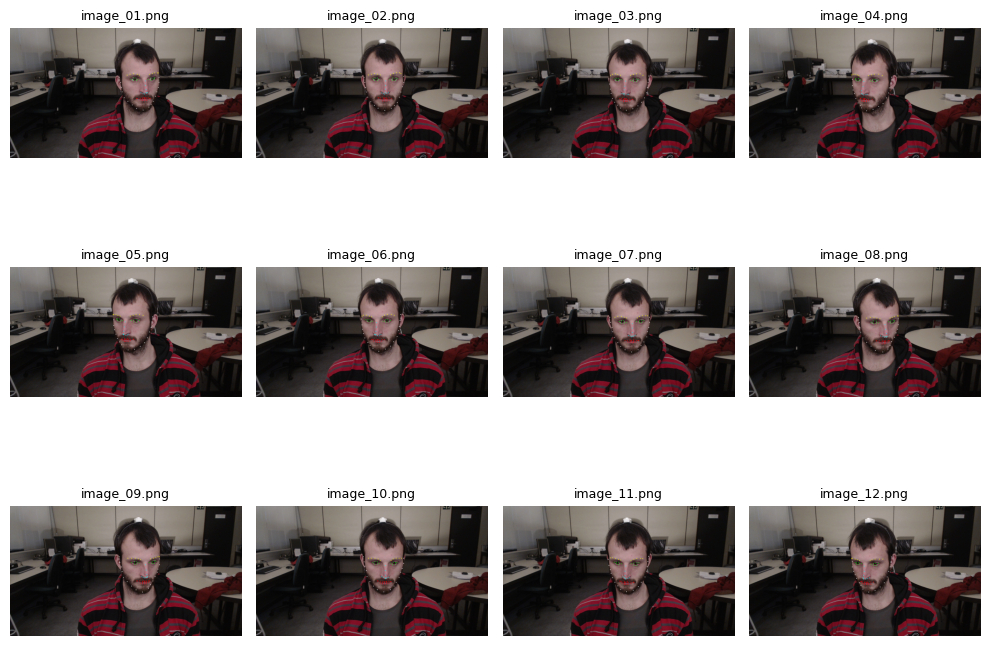

In [3]:
colors = {
    "Jaw": (JAW, 255, 255, 255),
    "Eyebrows": (EYEBROWS, 255, 255, 0),
    "Nose": (NOSE, 0, 255, 255),
    "Eyes": (EYES, 0, 255, 0),
    "Mouth": (MOUTH, 255, 0, 0)
}

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()
fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, flip_input=False, device='cpu')
    
for idx, test_image in enumerate(test_images):
    img = cv2.imread(test_image)
    print(f"Processing {test_image} with shape {img.shape}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    landmarks = fa.get_landmarks(img)[0] 
    img_points = img.copy()

    for name, (part, r, g, b) in colors.items():
        points = landmarks[part]
        for x, y in points:
            cv2.circle(img_points, (int(x), int(y)), radius=2, color=(r, g, b), thickness=-1)

    axes[idx].imshow(img_points)
    axes[idx].set_title(os.path.basename(test_image), fontsize=9)
    axes[idx].axis('off')

for idx in range(len(test_images), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

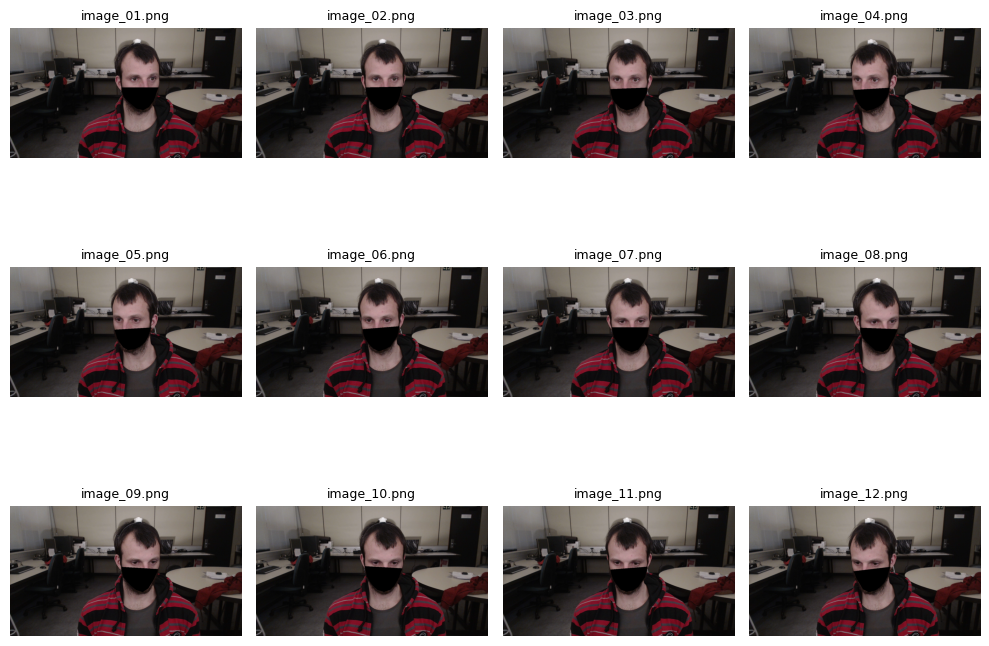

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()

for idx, test_image in enumerate(test_images):
    img = cv2.imread(test_image)
    if img is None:
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    preds = fa.get_landmarks(img)
    
    if preds is not None and len(preds) > 0:
        landmarks = preds[0].astype(np.int32)
        occluded_img = utils.apply_occlusion(img, landmarks, mode="mask")
        axes[idx].imshow(occluded_img)
    else:
        axes[idx].imshow(img)
        
    axes[idx].set_title(os.path.basename(test_image), fontsize=9)
    axes[idx].axis('off')

for idx in range(len(test_images), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

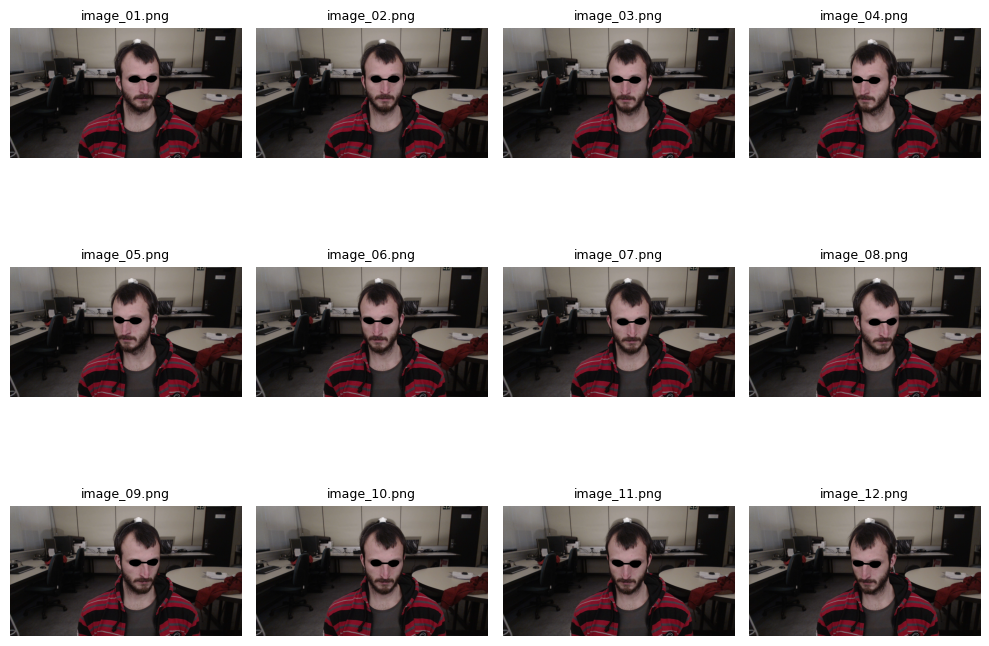

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()

for idx, test_image in enumerate(test_images):
    img = cv2.imread(test_image)
    if img is None:
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    preds = fa.get_landmarks(img)
    
    if preds is not None and len(preds) > 0:
        landmarks = preds[0].astype(np.int32)
        occluded_img = utils.apply_occlusion(img, landmarks, mode="glasses")
        axes[idx].imshow(occluded_img)
    else:
        axes[idx].imshow(img)
        
    axes[idx].set_title(os.path.basename(test_image), fontsize=9)
    axes[idx].axis('off')

for idx in range(len(test_images), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Downloading of the new test datasets

In [17]:
import os
import cv2
import numpy as np


input_dir = "./dataset/test"
modes = ["mask", "glasses", "both"]

for mode in modes:
    os.makedirs(os.path.join(input_dir, mode), exist_ok=True)

all_files = os.listdir(input_dir)
test_images = [f for f in all_files if f.endswith('.png') or f.endswith('.jpg')]

print(f"Found {len(test_images)} images to process.")

for filename in test_images:
    img_path = os.path.join(input_dir, filename)
    img = cv2.imread(img_path)
    
    if img is None:
        continue
        
    basename, ext = os.path.splitext(filename)
    parts = basename.split('_')
    person = parts[0]
    img_number = parts[2]
    
    mat_original = os.path.join(input_dir, f"{basename}.mat")
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    preds = fa.get_landmarks(img_rgb)
    
    if preds is not None and len(preds) > 0:
        landmarks = preds[0].astype(np.int32)
        
        for mode in modes:
            occluded_rgb = utils.apply_occlusion(img_rgb, landmarks, mode=mode)
            occluded_bgr = cv2.cvtColor(occluded_rgb, cv2.COLOR_RGB2BGR)
            
            new_img_name = f"{basename}_{mode}{ext}"
            new_mat_name = f"{basename}_{mode}.mat"
            
            dest_folder = os.path.join(input_dir, mode)
            dest_img_path = os.path.join(dest_folder, new_img_name)
            dest_mat_path = os.path.join(dest_folder, new_mat_name)
            
            cv2.imwrite(dest_img_path, occluded_bgr)
            
            if os.path.exists(mat_original):
                shutil.copy(mat_original, dest_mat_path)
            else:
                print(f"Warning: .mat file not found for {filename}")

print("Processing completed successfully.")


Found 328 images to process.
Processing completed successfully.
